### LASSO Activity

# Predictive Modeling of $f(x)$

You are interested in learning about a function $f(x)$. However, you cannot observe $f(x)$ directly, but rather observe only a noisy version. In other words, when you plug in a value for $x$ you observe $f(x)$ plus some noise:

$$y_i=f(x_i) + \varepsilon_i$$

You have obtained 10 pairs of data points $(x_1, y_1), (x_2, y_2), \dots, (x_{10}, y_{10})$.

```python
df = pd.DataFrame({
   "x1": [-1, -0.78, -0.56, -0.33, -0.11, 0.11, 0.33, 0.56, 0.78, 1],
   "y": [-1.09, -0.19, 0.04, 1.07, 1.98, 2.32, 1.63, 1.98, 1.11, 1.37]
})
```

Create a plot to investigate the relationship between `x` and `y`. What do you observe?

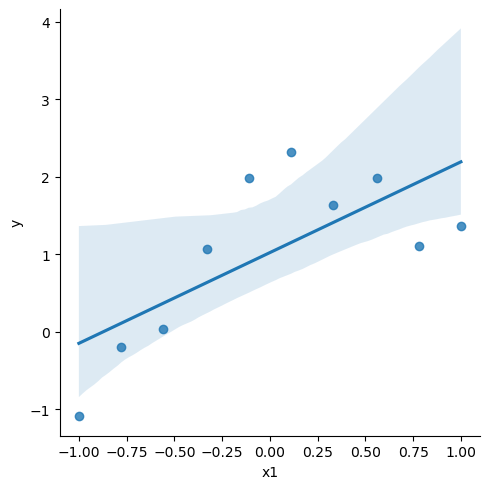

In [1]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame({
   "x1": [-1, -0.78, -0.56, -0.33, -0.11, 0.11, 0.33, 0.56, 0.78, 1],
   "y": [-1.09, -0.19, 0.04, 1.07, 1.98, 2.32, 1.63, 1.98, 1.11, 1.37]
})

sns.lmplot(data=df, x="x1", y="y")

The relationship looks almost linear, but there appears to be some nonlinearity as well.

#### Estimating $f(x)$ Using Simple Linear Regression

Now, fit a simple linear regression model for `x` and `y`. Look at the residuals of this model. What do you observe?

<Axes: ylabel='y'>

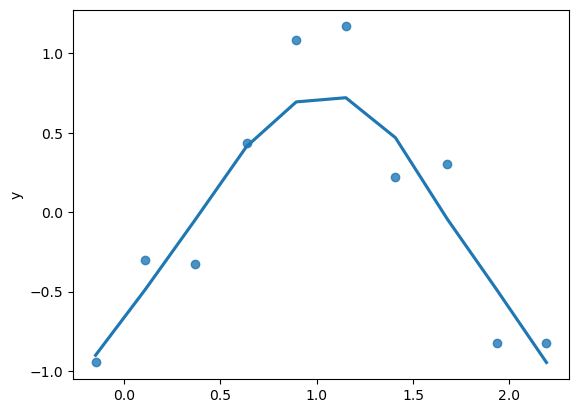

In [2]:
from sklearn.linear_model import LinearRegression

slr_model = LinearRegression()

X = df[["x1"]]
y = df["y"]

slr_model.fit(X, y)

slr_preds = slr_model.predict(X)
slr_resids = y - slr_preds

sns.regplot(x=slr_preds, y=slr_resids, lowess=True)

The residuals indicate there is a quadratic trend not being captured by our simple linear regression model.

#### Estimating $f(x)$ Using Polynomial Regression Models

You want to see if you can find a model that can be used to perfectly predict `y` from `x`. You decide to fit models of the following form:

$$y_i = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_n x^n + \varepsilon_i$$

Start fitting these models, first with $n=1$ (simple linear regression) all the way until $n=9$. Record your observations about the following:

- What do you notice happens to the RMSE as you add more parameters?
- What do you notice about your estimates for the coefficients as you add more parameters?

<Axes: >

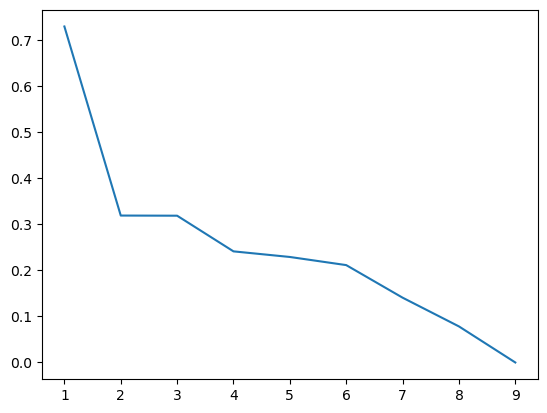

In [3]:
import numpy as np
from sklearn.metrics import root_mean_squared_error

for i in range(2, 10):
    df["x"+str(i)]=df["x1"]**i

poly_model = LinearRegression()
rmse_values = []
coef_values = {}
intercept_values = {}
coef_abs_sum = []
y = df["y"]

for i in range(1, 10):
    predictors = ["x"+str(j) for j in range(1,i+1)]
    X = df[predictors]
    poly_model.fit(X, y)
    poly_preds = poly_model.predict(X)
    rmse_values.append(root_mean_squared_error(y, poly_preds))
    coef_abs_sum.append(np.abs(poly_model.coef_).sum())
    intercept_values["model"+str(i)] = poly_model.intercept_
    coef_values["model"+str(i)] = poly_model.coef_

sns.lineplot(x=np.arange(1, 10, 1), y=rmse_values)

[1.17048458]
[ 1.17048458 -1.82477747]
[ 1.22473425 -1.82477747 -0.07486119]
[ 1.22473425 -3.94219234 -0.07486119  2.09576784]
[ 1.71453865 -3.94219234 -2.09074528  2.09576784  1.57782148]
[ 1.71453865 -6.19779629 -2.09074528  8.33717655  1.57782148 -4.13122971]
[  0.10017951  -6.19779629  12.45507455   8.33717655 -29.53342073
  -4.13122971  18.20702477]
[  0.10017951 -13.3576468   12.45507455  50.33387395 -29.53342073
 -79.21702192  18.20702477  40.07639714]
[   1.74809713  -13.3576468   -18.06282942   50.33387395  111.20799568
  -79.21702192 -207.01306366   40.07639714  113.34980027]


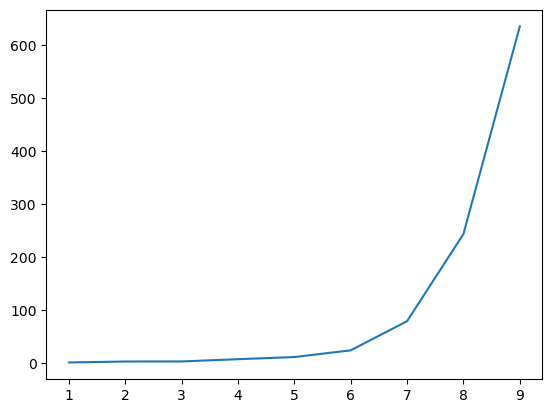

In [4]:
sns.lineplot(x=np.arange(1, 10, 1), y=coef_abs_sum)

for i in range(1, 10):
    print(coef_values["model"+str(i)])

The RMSE always decreases. The coefficients get larger and larger as we add more predictors to the model.

#### Comparing Different Estimates of $f(x)$

Consider the model for $n=2$ as well as the model for $n=9$. Plot these functions across a range of values from -1 to 1. Record your observations about the following:

- What do you notice about the difference between the two functions?
- Why do you think they are different?

<Axes: xlabel='x1', ylabel='y'>

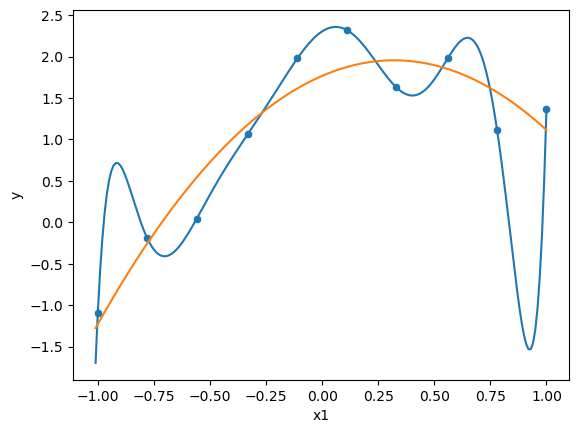

In [11]:
m2_b0 = intercept_values["model2"]
m2_coef = coef_values["model2"]

m9_b0 = intercept_values["model9"]
m9_coef = coef_values["model9"]

def f2(x, m2_b0, m2_coef):
    val = m2_b0 + m2_coef[0]*x + m2_coef[1]*x**2
    return val

def f9(x, m9_b0, m9_coef):
    val = (m9_b0 + m9_coef[0]*x + m9_coef[1]*x**2 + m9_coef[2]*x**3 + m9_coef[3]*x**4 +
           m9_coef[4]*x**5 + m9_coef[5]*x**6 + m9_coef[6]*x**7 + m9_coef[7]*x**8 + m9_coef[8]*x**9)
    return val

x_seq = np.arange(-1.01, 1.01, 0.01)

y2 = f2(x_seq, m2_b0, m2_coef)
y9 = f9(x_seq, m9_b0, m9_coef)

sns.scatterplot(df, x="x1", y="y")
sns.lineplot(x=x_seq, y=y9)
sns.lineplot(x=x_seq, y=y2) 

The model with more predictors and higher-order polynomials fits the data perfectly, but is very flexible ("wiggly"). The model with just the linear and quadratic terms doesn't fit the data perfectly, but captures the overall trend well. It is also smoother and seems more stable.

#### Predicting New Observations

You've been given another set of observations:

```python
df_test = pd.DataFrame({
   "x": [-0.9, -0.7, -0.5, -0.3, -0.1, 0.1, 0.3, 0.5, 0.7, 0.9],
   "y": [-0.08, 0.59, 0.78, 1.94, 2.22, 2.16, 1.75, 2.1, 2.49, 1.95]
})
```

You would like to test your models on this new set of observations. For each of the models where $n=1$ to $n=9$, obtain predictions for `y` in the test dataset using `x` in the test dataset. Record your observations about the following:

- What happens to your predictions for the new observations?
- Why do you think this is happening?
- Which of the models appears to be best for predicting these new observations?

<Axes: xlabel='x1', ylabel='y'>

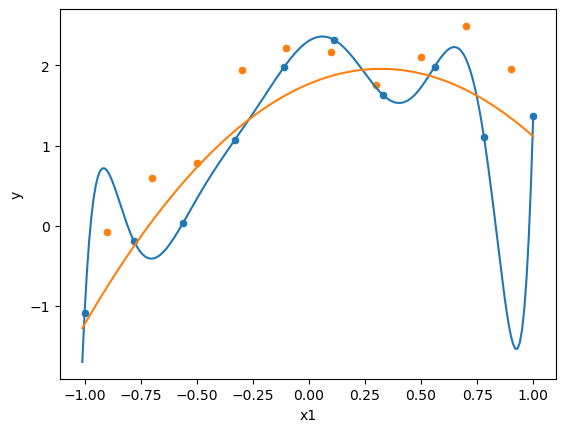

In [6]:
df_test = pd.DataFrame({
   "x1": [-0.9, -0.7, -0.5, -0.3, -0.1, 0.1, 0.3, 0.5, 0.7, 0.9],
   "y": [-0.08, 0.59, 0.78, 1.94, 2.22, 2.16, 1.75, 2.1, 2.49, 1.95]
})

sns.scatterplot(df, x="x1", y="y")
sns.scatterplot(df_test, x="x1", y="y")
sns.lineplot(x=x_seq, y=y9)
sns.lineplot(x=x_seq, y=y2)

<Axes: >

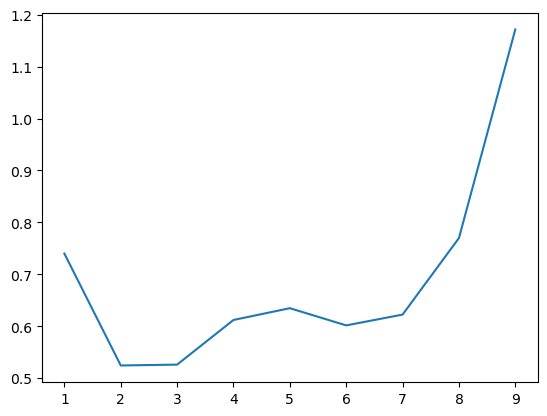

In [7]:
test_rmse_values = []
y_test = df_test["y"]

for i in range(2, 10):
    df_test["x"+str(i)]=df_test["x1"]**i

for i in range(1, 10):
    predictors = ["x"+str(j) for j in range(1,i+1)]
    X = df[predictors]
    X_test = df_test[predictors]
    poly_model.fit(X, y)
    poly_preds = poly_model.predict(X_test)
    test_rmse_values.append(root_mean_squared_error(y_test, poly_preds))

sns.lineplot(x=np.arange(1, 10, 1), y=test_rmse_values)

As the model becomes more complex, it doesn't predict as well on unseen observation (the test dataset). It looks like the simpler models actually perform better when predicting on unseen observations.

The simplest linear regression model also has some defects though when it comes to predicting new observations.

#### LASSO Criterion Function

Until now you have been fitting models by focusing solely on finding estimates of model parameters that minimize RMSE:

$$\frac{1}{n} \sum_{i=1}^n \left(y_i - \hat{y}_i \right)^2$$

You hear about LASSO regression and learn that it seeks to find estimates of model parameters that that minimize the following:

$$\frac{1}{n} \sum_{i=1}^n \left(y_i - \hat{y}_i \right)^2 + \alpha \sum_{j=1}^J \lvert \beta_j \rvert$$

Using `x` and `y` from the training dataset, fit regression models again. For each of the models that you fit, instead of computing RMSE, compute the error function for LASSO regression. For now, try small values of $\alpha$ like $\alpha = 0.05$ or $\alpha = 0.1$. Record your observations about the following:

- What happens to this new quantity as you add more parameters?
- Why do you think this is happening?

<Axes: >

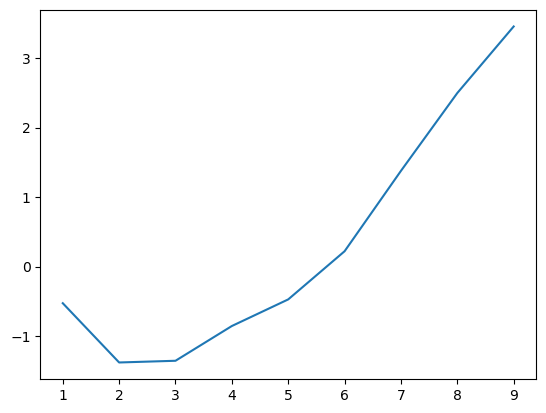

In [8]:
def log_lasso_criterion(y, y_hat, alpha, coef):
    n = y.size
    lasso_criterion = np.log(1/n*((y-y_hat)**2).sum() + alpha*(np.absolute(coef)).sum())
    return lasso_criterion

lasso_criterion_values = []

for i in range(1, 10):
    predictors = ["x"+str(j) for j in range(1,i+1)]
    X = df[predictors]
    poly_model.fit(X, y)
    poly_preds = poly_model.predict(X)
    lasso_criterion_values.append(log_lasso_criterion(y, poly_preds, .05, poly_model.coef_))

sns.lineplot(x=np.arange(1, 10, 1), y=lasso_criterion_values)

This looks more similar to what we saw when computing the test RMSE. However, this is done on the training data. We can see that adding some polynomials early on slightly decreases the value of the LASSO objective function, but then increases it again as the model becomes more complex.

We can see that we would probably choose a model with just the quadratic or maybe the cubic terms.

#### Role of $\alpha$ in LASSO Criterion Function

Now, do the same thing as before, but try picking new values for $\alpha$. Record your observations about the following:

- What do you notice happens as you increase $\alpha$?
- What do you think would happen if $\alpha=0$?

<Axes: ylabel='0'>

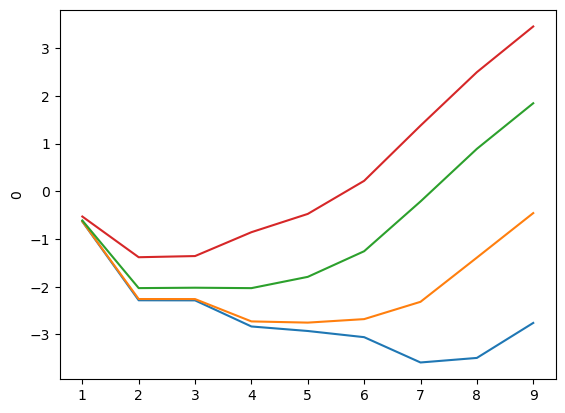

In [9]:
alpha_values = [0.0001, 0.001, 0.01, 0.05]

lasso_criterion_values = []

for alpha in alpha_values:
    criterion_values = []
    for i in range(1, 10):
        predictors = ["x"+str(j) for j in range(1,i+1)]
        X = df[predictors]
        poly_model.fit(X, y)
        poly_preds = poly_model.predict(X)
        criterion_values.append(log_lasso_criterion(y, poly_preds, alpha, poly_model.coef_))

    lasso_criterion_values.append(criterion_values)

df_lasso_values = pd.DataFrame(lasso_criterion_values)

sns.lineplot(x=np.arange(1, 10, 1), y=df_lasso_values.iloc[0,:])
sns.lineplot(x=np.arange(1, 10, 1), y=df_lasso_values.iloc[1,:])
sns.lineplot(x=np.arange(1, 10, 1), y=df_lasso_values.iloc[2,:])
sns.lineplot(x=np.arange(1, 10, 1), y=df_lasso_values.iloc[3,:])

This is a plot of the LASSO criterion (on the log scale) for increasingly complex models for different values of $\alpha$ ($\alpha=0.0001$ is blue, $\alpha=0.001$ is orange, $\alpha=0.01$ is green, and $\alpha=0.05$ is red.

We can see that when $\alpha$ is small, more complex models have a lower value for the criterion. As $\alpha$ increases, less complex models have the lower value for the criterion. This is why $\alpha$ is a regularization parameter. As it increases, it favors less complex models and as it decreases, it favors more complex models.

#### Predicting New Observations, Revisited

Consider one of the models for which the LASSO regression criterion function was small. Now, use this model to get predictions for `y` given `x` from the test dataset. Record your observations about the following:

- How well does this model predict new observations?
- If you had to choose a model to predict the new set of observations, what model would you choose?

In [10]:
X_alpha_05 = df[["x1", "x2"]]
X_test_alpha_05 = df_test[["x1", "x2"]]

poly_model.fit(X_alpha_05, y)
poly_preds = poly_model.predict(X_test_alpha_05)

print("RMSE: ", root_mean_squared_error(y_test, poly_preds))

RMSE:  0.5243643783488866


It looks that when $\alpha=0.05$, that the simplest model that performs well is the one with a linear and a quadratic term. We can see that the RMSE for the test is much lower using this model than when we used more complex models to predict unseen observations.

(This in fact was the model used to generate the data).